# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import boto3
import s3fs
import json
import re
import tarfile 
import xgboost as xgb_lib
# Weather data library
from meteostat import Stations, Daily
from datetime import datetime
from pyathena import connect

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

import sagemaker
from sagemaker.inputs import TrainingInput
from sagemaker import image_uris
from sagemaker.serializers import CSVSerializer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score, precision_score,recall_score, f1_score,ConfusionMatrixDisplay)
                                

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


# Connect SageMaker to S3

In [2]:
#Create S3 client using boto3
#This allows the notebook to communicate with S3
s3 = boto3.client('s3')

#Define your S3 bucket name where your datasets are stored
bucket = "vegetation-risk-ml"

#list files inside bucket
response = s3.list_objects_v2(Bucket=bucket)


# Load ML dataset from S3

In [3]:
vegetation_risk_data = pd.read_parquet("s3://vegetation-risk-ml/final/ml_ready/vegetation_ml_dataset.parquet")

print(vegetation_risk_data.shape)
vegetation_risk_data.head()

(243820, 25)


,dia,ht,slope,regional_drybiot,lat,lon,countycd,fire_count,max_fire_size,avg_fire_size,...,avg_wind,weather_distance_miles,fuel_moisture_risk,fire_recurrence,fuel_load_density,wildfire_risk_score,trim_priority,log_fire_size,fire_month_sin,fire_month_cos
0,10.2,46.0,35.0,404.669221,32.677701,-116.727918,73,2,263.0,156.5,...,11.297753,15.744269,15.883586,1.098612,12.154104,0.476166,High,5.575949,-1.0,-1.836970e-16
1,5.2,21.0,0.0,73.837135,32.692853,-116.508686,73,1,25.0,25.0,...,11.362007,5.792634,21.553977,0.693147,8.995167,0.331367,Medium,3.258097,-0.5,-8.660254e-01
2,6.0,23.0,0.0,108.927059,32.692853,-116.508686,73,1,25.0,25.0,...,11.362007,5.792634,21.553977,0.693147,9.617999,0.343172,Medium,3.258097,-0.5,-8.660254e-01
3,3.3,23.0,0.0,27.219884,32.761664,-116.727392,73,1,16390.0,16390.0,...,11.297753,18.134465,15.883586,0.693147,7.633848,0.257738,Low,9.704488,-1.0,-1.836970e-16
4,5.0,14.0,35.0,52.318863,32.761664,-116.727392,73,1,16390.0,16390.0,...,11.297753,18.134465,15.883586,0.693147,8.206125,0.268584,Low,9.704488,-1.0,-1.836970e-16


# Select features for training

In [4]:
#Map trim_priority to numeric labels
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
vegetation_risk_data['target'] = vegetation_risk_data['trim_priority'].map(mapping)
if vegetation_risk_data['target'].isnull().any():
    print("Some trim_priority values were not mapped and resulted in NaN in the target column.")
else:
    print("All trim_priority values successfully mapped to target labels.")


#Save lat/lon/county before split
meta = vegetation_risk_data[['lat', 'lon', 'countycd']].copy().reset_index(drop=True)

All trim_priority values successfully mapped to target labels.


In [5]:
# Select features and target variable
features=['dia', 'ht', 'slope', 'regional_drybiot', 'fire_recurrence', 'avg_temp', 'avg_rain', 'avg_wind', 'fuel_moisture_risk', 'log_fire_size','fire_month_sin', 'fire_month_cos']

X = vegetation_risk_data[features].reset_index(drop=True)
y = vegetation_risk_data["target"].reset_index(drop=True)


# Train Test Split

In [6]:
#Use a stratified 70,15,15 (training,testing,validation) split to preserve class distribution across all three priority levels
#Split into 70% train, 30% temp (which will be further split into val and test)
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(X, y, X.index, test_size=0.30, random_state=42, stratify=y)

# Split temp into 15% val, 15% test
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(X_temp, y_temp, idx_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Reset indices to avoid misalignment
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Validation shape:", X_val.shape)

Train shape: (170674, 12)
Test shape: (36573, 12)
Validation shape: (36573, 12)


# Save Splits to S3

In [7]:
#Save and upload all three splits
def save_to_s3(X, y, bucket, key):
    df = pd.concat([y.reset_index(drop=True), X.reset_index(drop=True)], axis=1)
    df.to_csv(f's3://{bucket}/{key}', header=False, index=False)

BUCKET = 'vegetation-risk-ml'
save_to_s3(X_train, y_train, BUCKET, 'ml/train/train.csv')
save_to_s3(X_val,   y_val,   BUCKET, 'ml/val/val.csv')
save_to_s3(X_test,  y_test,  BUCKET, 'ml/test/test.csv')

# Training

This project uses the SageMaker built-in XGBoost algorithm, which provides a pre-configured container for model training without requiring custom scripts or containerization

In [8]:
#Set up SageMaker Estimator for XGBoost
role = sagemaker.get_execution_role()
session = sagemaker.Session()

# Retrieve the XGBoost container URI
container = image_uris.retrieve('xgboost', session.boto_region_name, '1.7-1')

#Create SageMaker Estimator for XGBoost
xgb = sagemaker.estimator.Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type='ml.m5.large', 
    output_path=f's3://{BUCKET}/ml/model-output/',
    disable_profiler=True,
    sagemaker_session=session
)
#Set hyperparameters for XGBoost
xgb.set_hyperparameters(
    num_class=3,
    objective='multi:softprob',
    eval_metric='mlogloss,merror',
    num_round=150,
    eta=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,    
    reg_alpha=0.1,
    seed=42
)
#Define training and validation data inputs for SageMaker
train_input = TrainingInput(f's3://{BUCKET}/ml/train/', content_type='text/csv')
val_input = TrainingInput(f's3://{BUCKET}/ml/val/', content_type='text/csv')

#Train the model
xgb.fit({'train': train_input, 'validation': val_input})
print('Training completed')

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-03-30-00-25-41-666


2026-03-30 00:25:44 Starting - Starting the training job...
2026-03-30 00:25:59 Starting - Preparing the instances for training...
2026-03-30 00:26:23 Downloading - Downloading input data...
2026-03-30 00:27:09 Downloading - Downloading the training image......
2026-03-30 00:28:15 Training - Training image download completed. Training in progress...../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-30 00:28:19.565 ip-10-0-225-241.ec2.internal:8 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-30 00:28:19.643 ip-10-0-225-241.ec2.internal:8 INFO profiler_config_parser.py:111] Unable to find config at /opt/ml/input/config/profilerconfig.json. Profiler is disabled.
[2026-03-30:00:

# Deploy

In [9]:
#Deploy the model to an endpoint
predictor = xgb.deploy(instance_type='ml.m5.large', initial_instance_count=1)

predictor.serializer = CSVSerializer()

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-03-30-00-30-14-431
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2026-03-30-00-30-14-431
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2026-03-30-00-30-14-431


------!

# Evaluation

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     12191
           1       0.98      0.98      0.98     12191
           2       0.99      0.99      0.99     12191

    accuracy                           0.99     36573
   macro avg       0.99      0.99      0.99     36573
weighted avg       0.99      0.99      0.99     36573

Accuracy: 0.9881880075465508


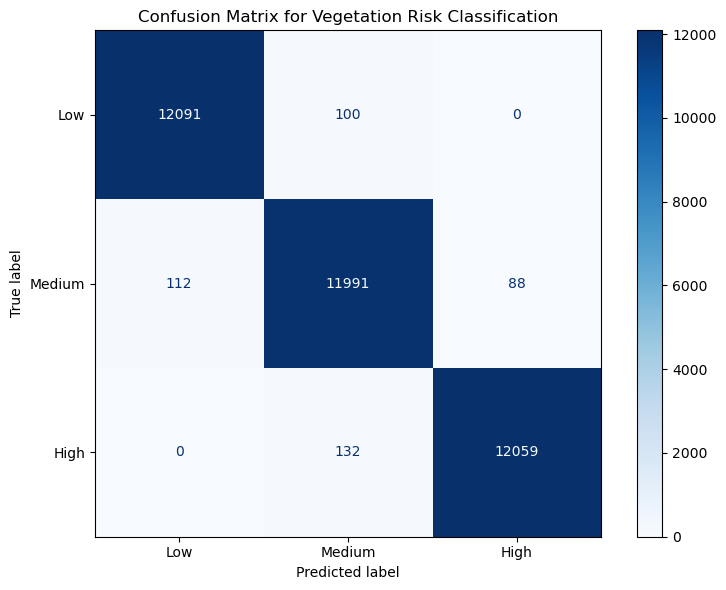

In [10]:

# Make predictions row by row on full test set
preds = []
for i in range(len(X_test)):
    r = predictor.predict(X_test.iloc[i].values)
    if isinstance(r, (bytes, bytearray)):
        r = r.decode('utf-8')
    row = list(map(float, r.strip().split(',')))
    preds.append(row)

probs = np.array(preds)
pred_class = np.argmax(probs, axis=1)

print(classification_report(y_test, pred_class))
print("Accuracy:", accuracy_score(y_test, pred_class))

# Plot confusion matrix
cm = confusion_matrix(y_test, pred_class)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Medium', 'High']
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix for Vegetation Risk Classification')
plt.tight_layout()
plt.show()

# Feature Importance

In [12]:
# Get model path from SageMaker
model_path = xgb.latest_training_job.describe()['ModelArtifacts']['S3ModelArtifacts']
print("Model:", model_path)

# Extract bucket & key automatically
bucket = model_path.split('/')[2]
key = '/'.join(model_path.split('/')[3:])

# Download model
boto3.client('s3').download_file(bucket, key, 'model.tar.gz')

# Extract model
with tarfile.open('model.tar.gz') as tar:
    tar.extractall()
    
#save feature map
feature_map_path = 'xgboost.fmap'
with open(feature_map_path, 'w') as f:
    for i, col in enumerate(X.columns):
        f.write(f"{i}\t{col}\tq\n")

# Load model
model = xgb_lib.Booster()
model.load_model('xgboost-model')
model.feature_names = list(X.columns)

Model: s3://vegetation-risk-ml/ml/model-output/sagemaker-xgboost-2026-03-30-00-25-41-666/output/model.tar.gz


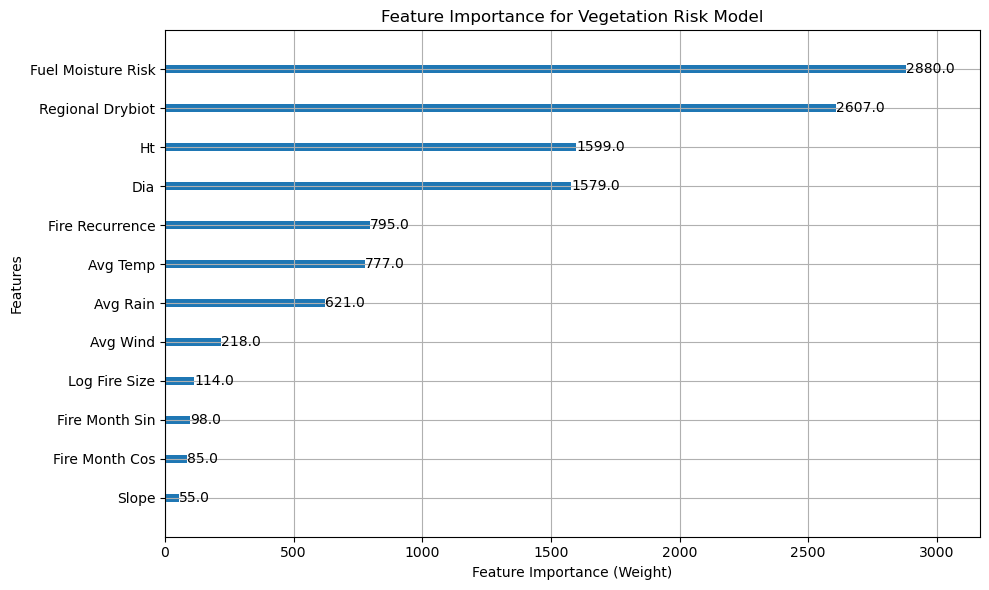

Feature Importance from Highest to Lowest:

fuel_moisture_risk : 2880.0
regional_drybiot : 2607.0
ht : 1599.0
dia : 1579.0
fire_recurrence : 795.0
avg_temp : 777.0
avg_rain : 621.0
avg_wind : 218.0
log_fire_size : 114.0
fire_month_sin : 98.0
fire_month_cos : 85.0
slope : 55.0


In [14]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
xgb_lib.plot_importance(
    model,
    ax=ax,
    max_num_features=12,
    importance_type='weight',
    title='Feature Importance for Vegetation Risk Model',
    xlabel='Feature Importance (Weight)',
    show_values=True,
)
# y-axis tick labels
ax.set_yticklabels([t.get_text().replace('_', ' ').title()
                    for t in ax.get_yticklabels()])
plt.tight_layout()
plt.show()

# Print features
importance_dict  = model.get_score(importance_type='weight')
sorted_importance = sorted(importance_dict.items(),key=lambda x: x[1], reverse=True)
print("Feature Importance from Highest to Lowest:\n")
for name, score in sorted_importance:
    print(f"{name} : {score}")

# Monitor Training with CloudWatch

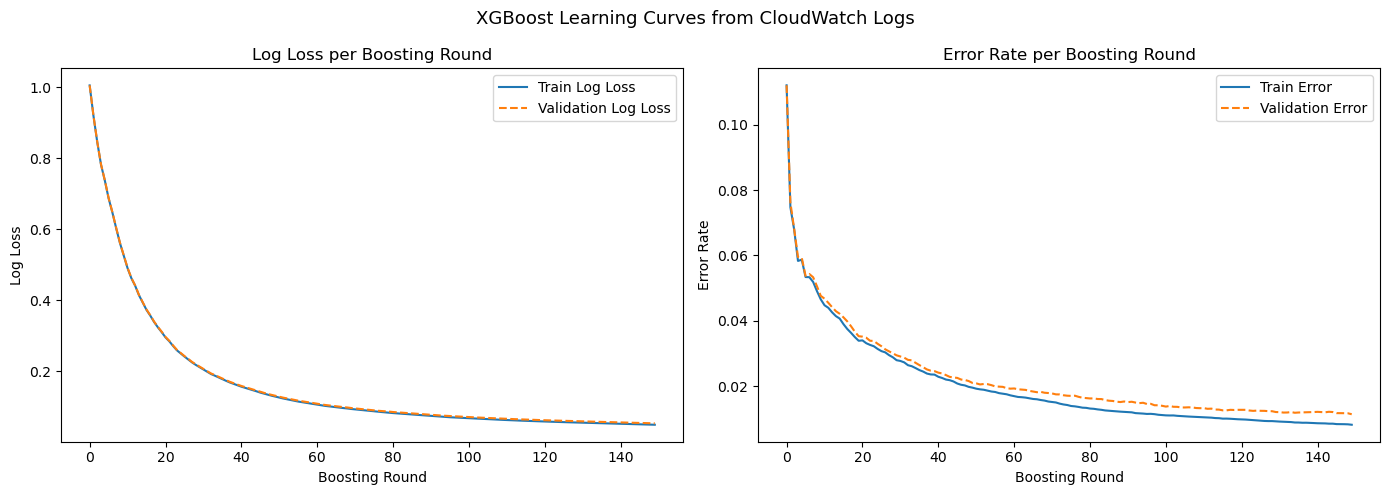


 Final Model Performance:
Train Log Loss:      0.04897
Validation Log Loss: 0.05296
Train Error:         0.00814 (0.81%)
Validation Error:    0.01135 (1.14%)
Generalization Gap:  0.32%


In [15]:

#Connect to CloudWatch Logs

logs_client = boto3.client('logs')
log_group = '/aws/sagemaker/TrainingJobs'
job_name = xgb.latest_training_job.name

#Get Latest Log Stream for the Job
response = logs_client.describe_log_streams(
    logGroupName=log_group,
    logStreamNamePrefix=job_name
)

streams = response.get('logStreams', [])

if not streams:
    print("No log streams found for this training job")
else:
    # Select most recent log stream
    log_stream = sorted(
        streams,
        key=lambda x: x.get('lastEventTimestamp', 0),
        reverse=True
    )[0]['logStreamName']

    # Retrieve All Log Events
    all_events = []
    next_token = None

    while True:
        kwargs = {
            'logGroupName': log_group,
            'logStreamName': log_stream,
            'startFromHead': True
        }

        if next_token:
            kwargs['nextToken'] = next_token

        response = logs_client.get_log_events(**kwargs)

        all_events.extend(response.get('events', []))

        # Stop when no new logs
        if next_token == response.get('nextForwardToken'):
            break

        next_token = response.get('nextForwardToken')
    #Extract Training Metrics from Logs
    train_mlogloss = []
    val_mlogloss   = []
    train_merror   = []
    val_merror     = []

    for event in all_events:
        msg = event['message']

        try:
            if 'train-mlogloss' in msg:
                match = re.search(r'train-mlogloss:([0-9\.]+)', msg)
                if match:
                    train_mlogloss.append(float(match.group(1)))

            if 'validation-mlogloss' in msg:
                match = re.search(r'validation-mlogloss:([0-9\.]+)', msg)
                if match:
                    val_mlogloss.append(float(match.group(1)))

            if 'train-merror' in msg:
                match = re.search(r'train-merror:([0-9\.]+)', msg)
                if match:
                    train_merror.append(float(match.group(1)))

            if 'validation-merror' in msg:
                match = re.search(r'validation-merror:([0-9\.]+)', msg)
                if match:
                    val_merror.append(float(match.group(1)))

        except:
            continue
    #Validate Extracted Data
    if len(train_mlogloss) == 0:
        print("No training metrics found in logs")
    else:
        # Ensure equal lengths
        min_len = min(
            len(train_mlogloss),
            len(val_mlogloss),
            len(train_merror),
            len(val_merror)
        )

        train_mlogloss = train_mlogloss[:min_len]
        val_mlogloss   = val_mlogloss[:min_len]
        train_merror   = train_merror[:min_len]
        val_merror     = val_merror[:min_len]

        rounds = list(range(min_len))
  
        #Plot Learning Curves
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        # Log Loss Plot
        axes[0].plot(rounds, train_mlogloss, label='Train Log Loss')
        axes[0].plot(rounds, val_mlogloss, label='Validation Log Loss', linestyle='--')
        axes[0].set_title('Log Loss per Boosting Round')
        axes[0].set_xlabel('Boosting Round')
        axes[0].set_ylabel('Log Loss')
        axes[0].legend()
        # Error Rate Plot
        axes[1].plot(rounds, train_merror, label='Train Error')
        axes[1].plot(rounds, val_merror, label='Validation Error', linestyle='--')
        axes[1].set_title('Error Rate per Boosting Round')
        axes[1].set_xlabel('Boosting Round')
        axes[1].set_ylabel('Error Rate')
        axes[1].legend()
        plt.suptitle('XGBoost Learning Curves from CloudWatch Logs', fontsize=13)
        plt.tight_layout()
        plt.show()

        #Print Final Metrics
        print("\n Final Model Performance:")
        print(f"Train Log Loss:      {train_mlogloss[-1]:.5f}")
        print(f"Validation Log Loss: {val_mlogloss[-1]:.5f}")
        print(f"Train Error:         {train_merror[-1]:.5f} ({train_merror[-1]*100:.2f}%)")
        print(f"Validation Error:    {val_merror[-1]:.5f} ({val_merror[-1]*100:.2f}%)")
        gap = abs(val_merror[-1] - train_merror[-1]) * 100
        print(f"Generalization Gap:  {gap:.2f}%")

# Batch Inference

In [16]:
# Save full data
X.to_csv('batch.csv', header=False, index=False)

# Upload to S3
boto3.client('s3').upload_file('batch.csv', BUCKET,'ml/batch-input/batch.csv')

#Set up batch transform job
transformer = xgb.transformer(
    instance_count=1,
    instance_type='ml.m5.large',
    output_path=f's3://{BUCKET}/ml/batch-output/',
    accept='text/csv'
)

#Start batch transform job on the full dataset
transformer.transform(
    data=f's3://{BUCKET}/ml/batch-input/',
    content_type='text/csv',
    split_type='Line'
)
#Wait for the batch transform job to complete
transformer.wait()

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-03-30-00-50-33-482
INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2026-03-30-00-50-34-226


................................./miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-30:00:56:03:INFO] No GPUs detected (normal if no gpus installed)
[2026-03-30:00:56:03:INFO] No GPUs detected (normal if no gpus installed)
[2026-03-30:00:56:03:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|i

# Process Batch Output

In [17]:
#Read batch predictions from S3
batch_preds = pd.read_csv(f's3://{BUCKET}/ml/batch-output/batch.csv.out',header=None)
print(batch_preds.head())

                        0         1                         2
0  [0.0001506845437688753  0.036072       0.9637771248817444]
1    [0.01644289493560791  0.983169   0.00038767815567553043]
2   [0.004510614089667797  0.994905    0.0005847361753694713]
3     [0.9980522394180298  0.001943    4.648223693948239e-06]
4     [0.9983490705490112  0.001647    4.054565124533838e-06]


In [18]:
# Get predicted class labels and risk scores from batch predictions
probs = batch_preds.copy()

probs[0] = probs[0].astype(str).str.replace('[', '', regex=False)
probs[2] = probs[2].astype(str).str.replace(']', '', regex=False)

# Convert to float
probs = probs.astype(float).values

# Predicted class is the one with highest probability
pred_class = np.argmax(probs, axis=1)
risk_score = probs[:, 1] * 50 + probs[:, 2] * 100


In [19]:
# Combine predictions with original data for analysis
results = vegetation_risk_data.copy()

# Add predictions and risk scores to results dataframe
results['predicted_class'] = pred_class
results['priority'] = pd.Series(pred_class).map({0:'Low',1:'Medium',2:'High'})
results['risk_score'] = risk_score.round(2)

# Reorder columns for better readability
results = results[features + ['lat', 'lon', 'countycd', 'priority', 'risk_score']]

# Sort results by risk score to identify highest risk areas
results = results.sort_values('risk_score', ascending=False)

print(results.head())


         dia     ht  slope  regional_drybiot  fire_recurrence   avg_temp  \
113769  39.4   98.0   55.0       9499.979096         0.693147  29.156305   
113768  30.0  108.0   55.0       6222.471639         0.693147  29.156305   
113763  16.6   92.0   55.0       1681.913042         0.693147  29.156305   
113764  24.0   65.0   53.0       2432.080740         0.693147  29.156305   
113765  24.5   95.0   53.0       3186.055238         0.693147  29.156305   

        avg_rain   avg_wind  fuel_moisture_risk  log_fire_size  \
113769  0.002346  11.024633           29.088063       3.044522   
113768  0.002346  11.024633           29.088063       3.044522   
113763  0.002346  11.024633           29.088063       3.044522   
113764  0.002346  11.024633           29.088063       3.044522   
113765  0.002346  11.024633           29.088063       3.044522   

        fire_month_sin  fire_month_cos        lat         lon  countycd  \
113769            -0.5       -0.866025  39.526948 -122.672546        21

In [20]:
# Verify class distribution looks reasonable
print(results['priority'].value_counts())
print(results['risk_score'].describe())

priority
Medium    81574
Low       81168
High      81078
Name: count, dtype: int64
count    243820.000000
mean         49.997013
std          39.840948
min           0.000000
25%           0.520000
50%          50.050000
75%          99.390000
max         100.000000
Name: risk_score, dtype: float64


# Save the results to S3

In [21]:
# Save predictions to S3
s3 = boto3.client('s3')

csv_buffer = results.to_csv(index=False)
s3.put_object(Bucket=BUCKET,Key='ml/predictions/test_predictions.csv',Body=csv_buffer)

print(" Test predictions saved")

 Test predictions saved


# Delete any endpoint

In [23]:
sagemaker_client = boto3.client('sagemaker')

# List all endpoints
endpoints = sagemaker_client.list_endpoints()

if endpoints['Endpoints']:
    for endpoint in endpoints['Endpoints']:
        name = endpoint['EndpointName']
        sagemaker_client.delete_endpoint(EndpointName=name)
        print(f"Deleted: {name}")
else:
    print("No endpoints to delete")

No endpoints to delete
